# Dodgers Deep Learning Project: Predicting Extra-Base Hits from Statcast Data

This notebook builds a **deep learning classification model** for Dodgers batted balls.

**Problem:** Given Statcast features for a Dodgers batted ball, predict whether the result will be an **extra-base hit (XBH)** — double, triple, or home run.


## 1) Environment setup

Run this cell once in your VS Code environment if needed.

In [1]:
pip install pybaseball pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2) Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pybaseball import statcast, cache

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

In [3]:
cache.enable()

START_DATE = "2024-04-01"
END_DATE = "2024-04-15"   # keep this small at first
TEAM = "LAD"
CACHE_PATH = "dodgers_statcast_raw.csv"

## 3) Download Dodgers Statcast data

This uses the Dodgers team code `LAD` and pulls pitch-level Statcast data for a date range.

Tip: Start with one season to keep the dataset manageable. You can widen the range later.

In [4]:
try:
    raw = pd.read_csv(CACHE_PATH)
    print(f"Loaded cached file: {CACHE_PATH}")
except FileNotFoundError:
    print("Downloading Statcast data...")
    raw = statcast(start_dt=START_DATE, end_dt=END_DATE, team=TEAM)
    raw.to_csv(CACHE_PATH, index=False)
    print(f"Saved cache to: {CACHE_PATH}")

print("Raw shape:", raw.shape)
raw.head()

This is a large query, it may take a moment to complete


100%|██████████| 15/15 [00:06<00:00,  2.31it/s]


Saved cache to: dodgers_statcast_raw.csv
Raw shape: (1897, 118)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
75,CU,2024-04-15,84.8,-1.9,5.71,"Vanasco, Ricky",682928,676568,field_out,hit_into_play,...,1,4.06,-0.05,0.05,50.7,20.480023,-8.479308,35.002736,40.710354,40.462403
77,CU,2024-04-15,84.7,-1.79,5.7,"Vanasco, Ricky",682928,676568,NaN,ball,...,1,4.21,-0.27,0.27,51.0,<NA>,<NA>,<NA>,<NA>,<NA>
78,FF,2024-04-15,95.2,-1.74,5.71,"Vanasco, Ricky",682928,676568,NaN,called_strike,...,1,0.97,0.84,-0.84,52.3,<NA>,<NA>,<NA>,<NA>,<NA>
80,CU,2024-04-15,84.3,-1.75,5.69,"Vanasco, Ricky",696285,676568,field_out,hit_into_play,...,1,4.22,-0.19,-0.19,50.5,4.404594,28.319444,23.118899,42.394365,15.62407
84,FF,2024-04-15,94.4,-1.7,5.59,"Vanasco, Ricky",696285,676568,NaN,foul,...,1,1.04,0.79,0.79,55.2,-1.720909,12.99691,31.255939,39.212633,20.469542


## 4) Data table of events

In [5]:
df = raw.copy()

# Keep rows with a recorded batted ball and known event outcome
df = df[df["launch_speed"].notna()].copy()
df = df[df["events"].notna()].copy()

# Target = extra-base hit
xbh_events = {"double", "triple", "home_run"}
df["is_xbh"] = df["events"].isin(xbh_events).astype(int)

candidate_features = [
    "launch_speed",
    "launch_angle",
    "hit_distance_sc",
    "estimated_ba_using_speedangle",
    "estimated_woba_using_speedangle",
    "balls",
    "strikes",
    "inning",
    "outs_when_up",
    "stand",
    "p_throws",
]

available_features = [c for c in candidate_features if c in df.columns]

model_df = df[available_features + ["is_xbh", "events", "player_name", "game_date"]].copy()
model_df = model_df.dropna(subset=available_features).reset_index(drop=True)

print("Filtered shape:", model_df.shape)
print("\nTarget balance:")
print(model_df["is_xbh"].value_counts(normalize=True).rename("share"))

model_df.head()

Filtered shape: (313, 15)

Target balance:
is_xbh
0    0.86901
1    0.13099
Name: share, dtype: float64


,launch_speed,launch_angle,hit_distance_sc,estimated_ba_using_speedangle,estimated_woba_using_speedangle,balls,strikes,inning,outs_when_up,stand,p_throws,is_xbh,events,player_name,game_date
0,93.0,6,92,0.558,0.526,1,1,9,2,L,R,0,field_out,"Vanasco, Ricky",2024-04-15
1,40.4,-85,0,0.166,0.276,2,2,9,1,R,R,0,field_out,"Vanasco, Ricky",2024-04-15
2,92.8,-14,12,0.163,0.156,1,1,8,2,L,R,0,field_out,"Vanasco, Ricky",2024-04-15
3,78.3,50,219,0.068,0.077,0,0,8,1,R,R,0,field_out,"Vanasco, Ricky",2024-04-15
4,96.2,19,290,0.355,0.398,1,1,8,0,L,R,0,field_out,"Vanasco, Ricky",2024-04-15


## 5) Train / test split

In [6]:
X = model_df[available_features]
y = model_df["is_xbh"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

categorical_features = [c for c in available_features if X[c].dtype == "object"]
numeric_features = [c for c in available_features if c not in categorical_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Numeric features: ['launch_speed', 'launch_angle', 'hit_distance_sc', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'balls', 'strikes', 'inning', 'outs_when_up']
Categorical features: ['stand', 'p_throws']
Train shape: (250, 11)
Test shape: (63, 11)


## 6) Preprocess features

We standardize numeric inputs and one-hot encode handedness features.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

## 7) Build the deep learning model

Architecture:
- Input layer
- Dense(64, ReLU)
- BatchNormalization
- Dropout(0.30)
- Dense(32, ReLU)
- Dropout(0.20)
- Dense(1, Sigmoid)

This is a **feedforward neural network / multilayer perceptron (MLP)** for binary classification.

In [8]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=42,
    ))
])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['launch_speed',
                                                   'launch_angle',
                                                   'hit_distance_sc',
                                                   'estimated_ba_using_speedangle',
                                                   'estimated_woba_using_speedangle',
                                                   'balls', 'strikes', 'inning',
                                                   'outs_when_up']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['stand', 'p_throws'])])),
                ('mlp',
                 MLPClassifier(alpha=0.001, batch_size=64, early_stopping=True,
                               hidden_layer_sizes=(64, 32), random_state=42,
                               validation_fraction=0.2))])

## 8) Train the model

We use:
- **EarlyStopping** to reduce overfitting
- **class weights** because extra-base hits are usually less common than non-XBH outcomes

In [9]:
model.fit(X_train, y_train)
print("Training complete.")

Training complete.


## 9) Evaluate the model

In [10]:
test_pred_prob = model.predict_proba(X_test)[:, 1]
test_pred_label = model.predict(X_test)

acc = accuracy_score(y_test, test_pred_label)
roc_auc = roc_auc_score(y_test, test_pred_prob)
pr_auc = average_precision_score(y_test, test_pred_prob)

print("── Test Metrics ──")
print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC:  {roc_auc:.3f}")
print(f"PR-AUC:   {pr_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred_label, digits=3))

── Test Metrics ──
Accuracy: 0.937
ROC-AUC:  0.943
PR-AUC:   0.759

Classification Report:
              precision    recall  f1-score   support

           0      0.932     1.000     0.965        55
           1      1.000     0.500     0.667         8

    accuracy                          0.937        63
   macro avg      0.966     0.750     0.816        63
weighted avg      0.941     0.937     0.927        63



## 10) Plot learning curves

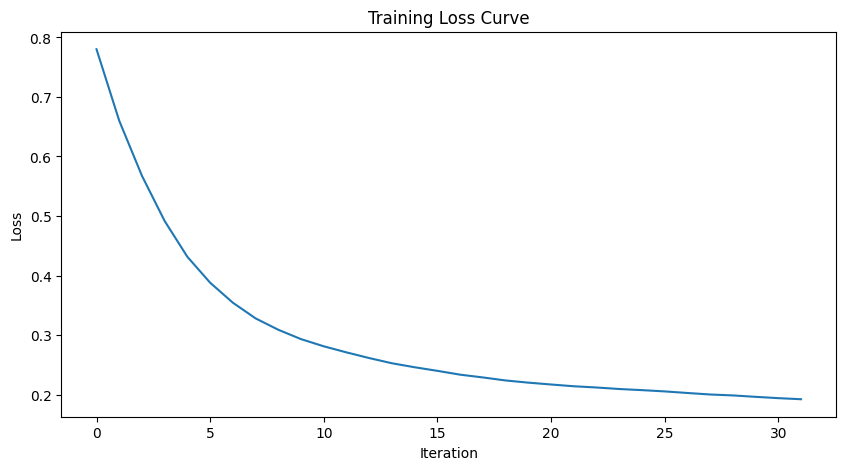

In [11]:
mlp_model = model.named_steps["mlp"]

plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## 11) ROC and precision-recall curves

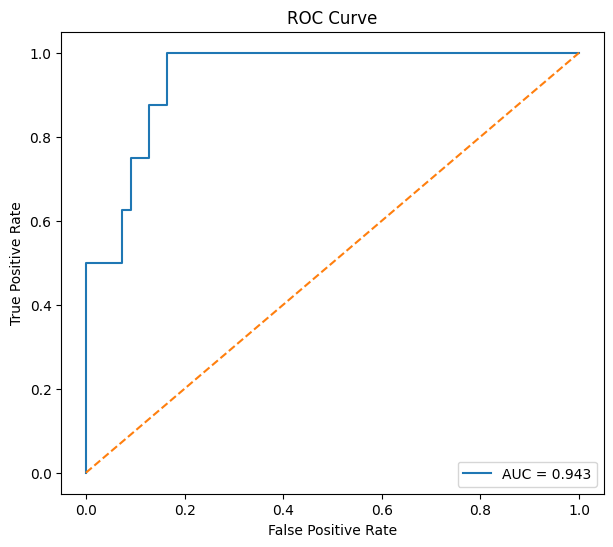

In [12]:
fpr, tpr, _ = roc_curve(y_test, test_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 12) Precision-recall curves

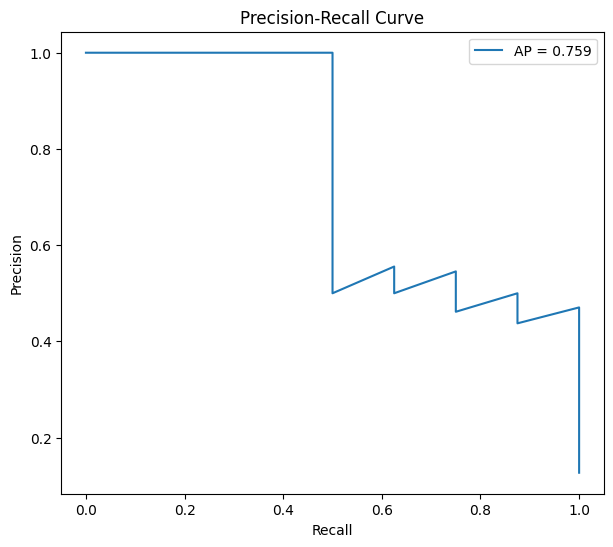

In [13]:
precision, recall, _ = precision_recall_curve(y_test, test_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## 13) Predicted probabilities based on metrics

In [14]:
results = X_test.copy().reset_index(drop=True)
results["actual_is_xbh"] = y_test.reset_index(drop=True)
results["predicted_xbh_probability"] = test_pred_prob

top_examples = results.sort_values("predicted_xbh_probability", ascending=False).head(15)

print("── Highest-Probability Extra-Base-Hit Forecasts ──")
top_examples

── Highest-Probability Extra-Base-Hit Forecasts ──


,launch_speed,launch_angle,hit_distance_sc,estimated_ba_using_speedangle,estimated_woba_using_speedangle,balls,strikes,inning,outs_when_up,stand,p_throws,actual_is_xbh,predicted_xbh_probability
0,112.0,32,452,0.966833,2.0,3,1,8,2,R,R,1,0.819461
34,104.5,26,418,0.761458,1.502966,1,1,4,0,R,L,1,0.630788
50,106.7,19,362,0.582522,0.946913,3,2,2,2,R,R,1,0.575908
26,103.3,25,372,0.674667,1.271783,0,0,6,2,L,L,1,0.544737
47,93.0,14,210,0.968,0.929,2,2,2,1,R,R,0,0.412397
46,99.4,32,369,0.396565,0.783565,0,1,4,2,R,L,0,0.405176
5,102.4,9,223,0.713,0.645,1,1,7,1,L,R,0,0.372431
28,87.1,15,192,0.968,0.931,1,0,5,1,L,R,0,0.365063
45,98.0,11,230,0.895,0.863,1,1,6,1,R,R,1,0.356476
60,99.9,39,332,0.252,0.4942,0,0,8,2,L,R,0,0.302237


In [15]:
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = list(ohe.get_feature_names_out(categorical_features))
all_features_after_preprocessing = numeric_features + encoded_cat_features

print("Number of model input features after preprocessing:", len(all_features_after_preprocessing))
print(all_features_after_preprocessing)

Number of model input features after preprocessing: 13
['launch_speed', 'launch_angle', 'hit_distance_sc', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'balls', 'strikes', 'inning', 'outs_when_up', 'stand_L', 'stand_R', 'p_throws_L', 'p_throws_R']
